# Experiment 1 on Common Voice Delta Segment 21.0 (https://commonvoice.mozilla.org/en/datasets)

## I wanted to work on Common Voice Corpus 21.0, but it is very large 85.6 GB and there is no time to train on this large dataset.

In [27]:
!pip install yt-dlp

  Using cached yt_dlp-2025.5.22-py3-none-any.whl.metadata (174 kB)
Using cached yt_dlp-2025.5.22-py3-none-any.whl (3.3 MB)


In [5]:
import pandas as pd

path = r"C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2025-03-14-en\cv-corpus-21.0-delta-2025-03-14\en\validated.tsv"
df = pd.read_csv(path, sep="\t")
print(df[['path', 'sentence', 'accents']].head())

                           path  \
0  common_voice_en_41923025.mp3   
1  common_voice_en_42356358.mp3   
2  common_voice_en_42165090.mp3   
3  common_voice_en_41921729.mp3   
4  common_voice_en_42528393.mp3   

                                            sentence                accents  
0  He was born at Wichenford, in Worcestershire, ...  United States English  
1  The Portuguese division was overrun and withdr...  United States English  
2            Her health by this stage was also poor.                    NaN  
3  His sporting interests outside of cricket incl...        England English  
4  The following year he was elected to be part o...  United States English  


In [7]:
print(df.columns.tolist())

['client_id', 'path', 'sentence_id', 'sentence', 'sentence_domain', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']


In [9]:
unique_accents = df['accents'].unique()
print("All accents in dataset:")
for accent in unique_accents:
    print("-", accent)


All accents in dataset:
- United States English
- nan
- England English
- Australian English,Canadian English
- Scottish English
- India and South Asia (India, Pakistan, Sri Lanka)
- Russian
- Filipino
- Malaysian English
- United States English,Southern United States English,Lightly Southern
- L2
- United States English,Filipino
- Lithuanian,Non-native
- British English / Received Pronunciation (RP)
- Canadian English
- nigerian accent


In [11]:
accent_counts = df['accents'].value_counts()
print("Accent distribution in dataset:")
print(accent_counts)

Accent distribution in dataset:
accents
nigerian accent                                                          95
United States English                                                    81
Canadian English                                                         31
British English / Received Pronunciation (RP)                             6
United States English,Filipino                                            5
Lithuanian,Non-native                                                     5
England English                                                           4
Scottish English                                                          4
India and South Asia (India, Pakistan, Sri Lanka)                         4
L2                                                                        3
United States English,Southern United States English,Lightly Southern     2
Australian English,Canadian English                                       1
Russian                                         

In [13]:
import os
clips_dir = r"C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2025-03-14-en\cv-corpus-21.0-delta-2025-03-14\en\clips"

df["audio_path"] = df["path"].apply(lambda x: os.path.join(clips_dir, x))

print(df[["audio_path", "sentence" ,"accents"]].head())

                                          audio_path  \
0  C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2...   
1  C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2...   
2  C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2...   
3  C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2...   
4  C:\Users\ASUS\Downloads\cv-corpus-21.0-delta-2...   

                                            sentence                accents  
0  He was born at Wichenford, in Worcestershire, ...  United States English  
1  The Portuguese division was overrun and withdr...  United States English  
2            Her health by this stage was also poor.                    NaN  
3  His sporting interests outside of cricket incl...        England English  
4  The following year he was elected to be part o...  United States English  


In [15]:
df["file_exists"] = df["audio_path"].apply(os.path.exists)
print(df["file_exists"].value_counts())

file_exists
True    249
Name: count, dtype: int64


## This function extracts the audio from any video. Of course, you don't need to save the video itself, just the URL.

In [17]:
import yt_dlp

def download_audio_yt_dlp(url, output_path="audio.wav", ffmpeg_path="C:\\Users\\ASUS\\ffmpeg\\ffmpeg.exe"):
    ydl_opts = {
        'format': 'bestaudio/best',
        'outtmpl': output_path.replace('.wav', '.%(ext)s'),
        'ffmpeg_location': ffmpeg_path,
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'wav',
            'preferredquality': '192',
        }],
        'quiet': True
    }

    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])
    return output_path


In [19]:
wav_path= download_audio_yt_dlp("https://www.youtube.com/watch?v=Ln_3AVoBRLk", ffmpeg_path="C:\\Users\\ASUS\\ffmpeg\\ffmpeg.exe")
print(f"Audio saved at: {wav_path}")

         player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         n = hTPOZRGNEELvY5u ; player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = 6Rlw__C8WPzE-VD ; player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = U9mOYLfvkZHuNNA ; player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


Audio saved at: audio.wav                                                


In [20]:
!pip install librosa

## Mfcc to extract features

In [21]:
import librosa
import numpy as np
from tqdm import tqdm


def extract_mfcc(file_path, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None


features = []
labels = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    mfcc = extract_mfcc(row['audio_path'])
    if mfcc is not None:
        features.append(mfcc)
        labels.append(row['accents'])

  0%|          | 0/249 [00:00<?, ?it/s]C:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
100%|██████████| 249/249 [00:03<00:00, 71.92it/s] 


## After applying several algorithms, I found that the best thing is SVM (Support Vector Machine)

In [22]:
 from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

clf = SVC(kernel='linear',probability=True)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

                                     precision    recall  f1-score   support

Australian English,Canadian English       0.00      0.00      0.00         0
                   Canadian English       1.00      1.00      1.00         2
                    England English       0.00      0.00      0.00         1
                           Filipino       0.00      0.00      0.00         1
              Lithuanian,Non-native       1.00      1.00      1.00         2
                   Scottish English       1.00      1.00      1.00         1
              United States English       0.71      0.83      0.77        18
     United States English,Filipino       0.50      1.00      0.67         1
                                nan       0.00      0.00      0.00         3
                    nigerian accent       0.89      0.81      0.85        21

                           accuracy                           0.76        50
                          macro avg       0.51      0.56      0.53        

C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\m

In [23]:
import joblib
joblib.dump(clf, "svm_accent_model.pkl")

['svm_accent_model.pkl']

## Function to predict Accent as a percentage 0-100

In [24]:
import joblib

def predict_accent(audio_path, model_path="svm_accent_model.pkl"):
    mfcc_features = extract_mfcc(audio_path).reshape(1, -1)
    clf = joblib.load(model_path)

    prediction = clf.predict(mfcc_features)[0]

    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(mfcc_features)[0]
        confidence = max(probas) * 100
    else:
        confidence = None

    return prediction, confidence

## Function to Generate Summary it's simple

In [25]:
def generate_summary(accent, confidence):
    # Normalize accent name to match explanation keys
    accent_map = {
        "United States English": "American",
        "England English": "British",
        "British English / Received Pronunciation (RP)": "British",
        "Scottish English": "British",
        "Canadian English": "Canadian",
        "Nigerian accent": "Nigerian",
        "India and South Asia (India, Pakistan, Sri Lanka)": "Indian",
        "Indian English": "Indian",
        "United States English,Filipino": "American",
        "Lithuanian,Non-native": "Non-native",
    }

    normalized_accent = accent_map.get(accent, "Unknown")

    # Determine confidence level
    if confidence >= 85:
        level = "high"
    elif confidence >= 60:
        level = "moderate"
    else:
        level = "low"

    # Explanation dictionary
    explanations = {
        "American": {
            "high": "Clearly pronounced R sounds and general rhoticity indicate an American accent.",
            "moderate": "Some rhotic patterns suggest an American influence, though not strongly pronounced.",
            "low": "Slight signs of American pronunciation, but not conclusive."
        },
        "British": {
            "high": "The lack of rhoticity and formal intonation suggests a strong British accent.",
            "moderate": "British speech patterns are partially observed.",
            "low": "Minor indicators of British intonation exist, but unclear."
        },
        "Canadian": {
            "high": "Rounded vowels and moderate rhoticity suggest a strong Canadian English accent.",
            "moderate": "Some phonetic features match Canadian English.",
            "low": "Weak indicators of Canadian English detected."
        },
        "Indian": {
            "high": "Pronunciation and rhythm clearly reflect Indian English, including syllable-timed patterns.",
            "moderate": "There are Indian English influences, though not entirely dominant.",
            "low": "Minor traits of Indian English detected, not conclusive."
        },
        "Nigerian": {
            "high": "Strong tonal quality and syllable-timed rhythm indicate Nigerian English.",
            "moderate": "Several pronunciation features match Nigerian English.",
            "low": "Some elements of Nigerian speech detected, but limited confidence."
        },
        "Non-native": {
            "high": "Pronunciation patterns suggest a fluent non-native English speaker.",
            "moderate": "Non-native patterns present with moderate fluency.",
            "low": "Limited fluency and clear non-native markers."
        },
        "Unknown": {
            "high": "Speech does not match known accent classes clearly.",
            "moderate": "Mixed or unclear patterns in speech.",
            "low": "Accent is difficult to classify."
        }
    }

    return explanations[normalized_accent][level]

## Model Core To perform all the previous Functions in one place and do the classification

In [26]:
def run_accent_detection_pipeline(video_url):
    print("[1] Downloading audio...")
    audio_path = download_audio_yt_dlp(video_url)

    print("[2] Predicting accent...")
    accent, confidence = predict_accent(audio_path)

    print(f"\n🗣️  Predicted Accent: {accent}")
    if confidence:
        print(f"✅ Confidence Score: {confidence:.2f}%")
        summary = generate_summary(accent, confidence)
        print(f"📝 Explanation: {summary}")
    else:
        print("⚠️ Model does not support confidence score.")

## Example 

In [37]:
video_url = "https://www.youtube.com/watch?v=z7MIyQS9p5E" 
ffmpeg_path="C:\\Users\\ASUS\\ffmpeg\\ffmpeg.exe"
run_accent_detection_pipeline(video_url)

[1] Downloading audio...


         player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         n = ybr7UJg2wDYMFmn ; player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = 1WjmAEqE5Xd-H9F ; player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U
         n = eOchisjKlkp2ei7 ; player = https://www.youtube.com/s/player/fc2a56a5/player_ias.vflset/en_US/base.js
         Please report this issue on  https://github.com/yt-dlp/yt-dlp/issues?q= , filling out the appropriate issue template. Confirm you are on the latest version using  yt-dlp -U


[2] Predicting accent...                                                

🗣️  Predicted Accent: United States English
✅ Confidence Score: 62.05%
📝 Explanation: Some rhotic patterns suggest an American influence, though not strongly pronounced.


## Experiment 2 on Common Voice Delta Segment 16.1 (https://commonvoice.mozilla.org/en/datasets)

### It is somewhat larger than the first one and better in terms of size and variety.

In [1]:
import pandas as pd
import os
import librosa
import numpy as np
from tqdm import tqdm
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import joblib
import yt_dlp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import LabelEncoder

In [2]:
path = r"G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en\cv-corpus-16.1-delta-2023-12-06\en\validated.tsv"
df = pd.read_csv(path, sep="\t")

In [3]:
print(df[['path', 'sentence', 'accents']].head())
print(df.columns.tolist())

                           path  \
0  common_voice_en_39584989.mp3   
1  common_voice_en_39576542.mp3   
2  common_voice_en_39582342.mp3   
3  common_voice_en_38497561.mp3   
4  common_voice_en_39263187.mp3   

                                            sentence  \
0  These locomotives are serviced at Washwood Heath.   
1  Here, she turned her inspirations towards writ...   
2       There is also a garnet mine in West Redding.   
3  They hastily drive to the plane, and flee from...   
4    They found one such edge in Fairbairn's system.   

                                             accents  
0                                                NaN  
1  England English,Esturine, from the region arou...  
2                                                NaN  
3        canadian - toronto english,Canadian English  
4                                                NaN  
['client_id', 'path', 'sentence', 'up_votes', 'down_votes', 'age', 'gender', 'accents', 'variant', 'locale', 'segment']


In [4]:
unique_accents = df['accents'].dropna().unique()
print("All accents in dataset:")
for accent in unique_accents:
    print("-", accent)

All accents in dataset:
- England English,Esturine, from the region around the Thames Estuary in England
- canadian - toronto english,Canadian English
- United States English
- Canadian English
- German English
- England English
- India and South Asia (India, Pakistan, Sri Lanka)
- Mancunian,British English,England English,Manchester, Speech Impediment
- Australian English
- Latvian English
- Mandarin English
- England English,yorkshire
- Russian English
- not native English, originally French native language
- Scottish English
- Argentine English
- India and South Asia (India, Pakistan, Sri Lanka),England English,Southern African (South Africa, Zimbabwe, Namibia)
- United States English,England English
- India and South Asia (India, Pakistan, Sri Lanka),Indian English 
- Dutch
- United States English,African American ,Midwestern Wisconsin,Midwestern,Wisconsin
- bulgarian english,non-native speaker
- Scottish English,Renfrewshire. Scotland
- India and South Asia (India, Pakistan, Sri L

In [5]:
accent_counts = df['accents'].value_counts()
print("Accent distribution in dataset:")
print(accent_counts)

Accent distribution in dataset:
accents
Southern African (South Africa, Zimbabwe, Namibia)                    1164
United States English                                                  653
Canadian English                                                       536
German English,Non native speaker                                      168
England English                                                        135
                                                                      ... 
Filipino,Canadian English                                                1
London, England                                                          1
Domincian                                                                1
United States English,New York,italian american                          1
hey you are you ok ,hello my friend,i love you,yes i am,ho are you       1
Name: count, Length: 87, dtype: int64


In [6]:
clips_dir = r"G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en\cv-corpus-16.1-delta-2023-12-06\en\clips"
df = df.dropna(subset=['accents'])
df = df[~df['accents'].str.contains(",")]

In [7]:
accent_map = {
"United States English": "American",
"England English": "British",
"Australian English": "Australian",
"Canadian English": "Canadian"
}
df = df[df['accents'].isin(accent_map.keys())]
df['label'] = df['accents'].map(accent_map)
df["audio_path"] = df["path"].apply(lambda x: os.path.join(clips_dir, x))
df["file_exists"] = df["audio_path"].apply(os.path.exists)
df = df[df["file_exists"] == True]

print(df[["audio_path", "sentence" ,"accents"]].head())
print(df["file_exists"].value_counts())

                                           audio_path  \
5   G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en...   
6   G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en...   
8   G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en...   
16  G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en...   
18  G:\My Drive\cv-corpus-16.1-delta-2023-12-06-en...   

                                             sentence                accents  
5                  Flatow was given a co-star credit.  United States English  
6   The ocean surrounding the islands is covered w...  United States English  
8         A timetable for the move was not specified.       Canadian English  
16  Mango and soursop ice cream are two popular de...  United States English  
18  He largely left active politics in his later l...  United States English  
file_exists
True    1344
Name: count, dtype: int64


In [64]:
def download_audio_yt_dlp(url, output_path="audio.wav", ffmpeg_path="C:\\Users\\ASUS\\ffmpeg\\ffmpeg.exe"):
    ydl_opts = {
        'format': 'bestaudio/best',
        'outtmpl': output_path.replace('.wav', '.%(ext)s'),
        'ffmpeg_location': ffmpeg_path,
        'postprocessors': [{
            'key': 'FFmpegExtractAudio',
            'preferredcodec': 'wav',
            'preferredquality': '192',
        }],
        'quiet': True
    }
    with yt_dlp.YoutubeDL(ydl_opts) as ydl:
        ydl.download([url])
    return output_path

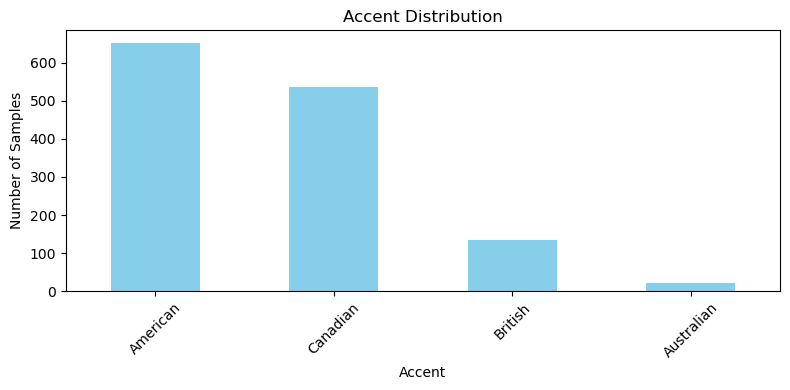

In [9]:
plt.figure(figsize=(8, 4))
df['label'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Accent Distribution")
plt.xlabel("Accent")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
def extract_mfcc(file_path, n_mfcc=13):
    try:
        y, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        return np.mean(mfcc.T, axis=0)
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

features = []
labels = []

for idx, row in tqdm(df.iterrows(), total=len(df)):
    mfcc = extract_mfcc(row['audio_path'])
    if mfcc is not None:
        features.append(mfcc)
        labels.append(row['label'])

  0%|          | 0/1344 [00:00<?, ?it/s]C:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
C:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
C:\Users\ASUS\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,
100%|██████████| 1344/1344 [01:49<00:00, 12.24it/s]


In [22]:
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.2, random_state=42)

In [24]:
clf = SVC(kernel='linear',probability=True)
clf.fit(X_train, y_train)

SVC(kernel='linear', probability=True)

In [25]:
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

    American       0.82      0.95      0.88       131
  Australian       0.00      0.00      0.00         3
     British       0.93      0.52      0.67        27
    Canadian       0.93      0.87      0.90       108

    accuracy                           0.86       269
   macro avg       0.67      0.58      0.61       269
weighted avg       0.87      0.86      0.86       269



In [52]:
joblib.dump(clf, "D:\\IT\\svm_accent_model.pkl")

['D:\\IT\\svm_accent_model.pkl']

In [54]:
def predict_accent(audio_path, model_path="D:\\IT\\svm_accent_model.pkl"):
    mfcc_features = extract_mfcc(audio_path).reshape(1, -1)
    clf = joblib.load(model_path)

    prediction = clf.predict(mfcc_features)[0]

    if hasattr(clf, "predict_proba"):
        probas = clf.predict_proba(mfcc_features)[0]
        confidence = max(probas) * 100
    else:
        confidence = None

    return prediction, confidence

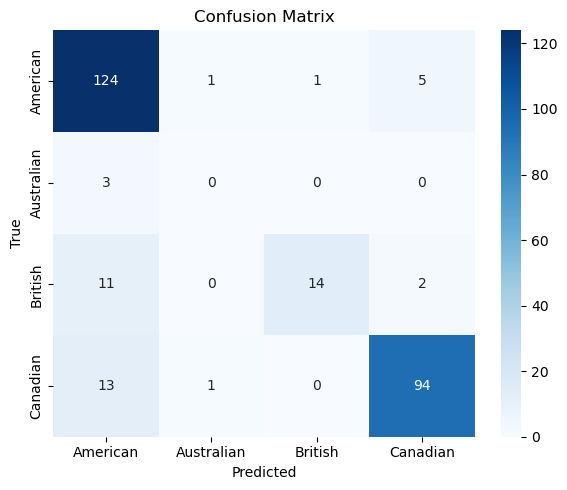

In [28]:
y_test_encoded = LabelEncoder().fit_transform(y_test)
y_pred_encoded = LabelEncoder().fit_transform(y_pred)

cm = confusion_matrix(y_test_encoded, y_pred_encoded)
labels = sorted(list(set(y_test)))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=labels, yticklabels=labels)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28384\2551228068.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=precision_scores, palette="viridis")


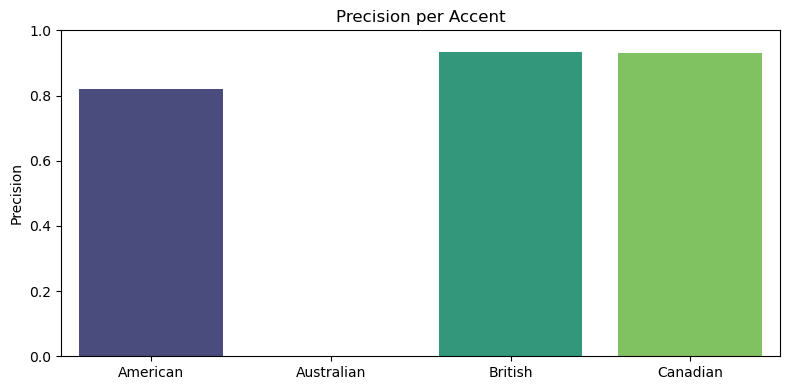

In [29]:
precision_scores = precision_score(y_test, y_pred, average=None, labels=labels)

plt.figure(figsize=(8, 4))
sns.barplot(x=labels, y=precision_scores, palette="viridis")
plt.title("Precision per Accent")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [78]:
def run_accent_detection_pipeline(video_url):
    try:
        audio_path = download_audio_yt_dlp(video_url, output_path="test_audio.wav")
        accent, confidence = predict_accent(audio_path)

        if confidence is not None:
            result = (
                f"🗣️ Predicted Accent: {accent}\n"
                f"🎯 Confidence: {confidence:.2f}%\n\n"
                
            )
        else:
            result = f"🗣️ Predicted Accent: {accent}\n⚠️ Model does not support confidence score."
        return result
    except Exception as e:
        return f"❌ Error: {str(e)}"


In [80]:
def process(video_url):
    return run_accent_detection_pipeline(video_url)

In [84]:
import gradio as gr

iface = gr.Interface(
    fn=process,
    inputs=gr.Textbox(label="YouTube Video URL"),
    outputs="text",
    title="English Accent Classifier",
    description="Paste a YouTube video URL to detect the speaker's English accent. Supported accents: American, British, Canadian, Australian."
)

iface.launch()

* Running on local URL:  http://127.0.0.1:7869
* To create a public link, set `share=True` in `launch()`.
